## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import streamlit as st
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
from xgboost import XGBRegressor
import warnings
from sklearn.linear_model import LinearRegression
import time
from sklearn.preprocessing import LabelEncoder

In [3]:
pd.set_option('display.max_rows', None) # Librerias de pandas
pd.set_option('display.max_columns', None) # Lo necesito por la exploración de datos

## Carga inicial del dataset

In [4]:
Data_hotel = pd.read_csv('hotel_booking.csv')
Data_hotel.count().to_frame()

,0
hotel,119390
is_canceled,119390
lead_time,119390
arrival_date_year,119390
arrival_date_month,119390
arrival_date_week_number,119390
arrival_date_day_of_month,119390
stays_in_weekend_nights,119390
stays_in_week_nights,119390
adults,119390


## Análisis de variables

### Información dataset

In [5]:
 # el tamaño que hay en el dataframe
len(Data_hotel)

119390

In [6]:
#información del dato
print(Data_hotel.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
# Ver nombres de columnas
print(Data_hotel.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')


In [ ]:
Data_hotel[["hotel","lead_time","arrival_date_month","stays_in_weekend_nights",
            "stays_in_week_nights","reserved_room_type","market_segment",
            "distribution_channel","adults","children","babies","adr"]].describe()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr
count,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103890,0.007949,101.831122
std,106.863097,0.998613,1.908286,0.579261,0.398561,0.097436,50.535790
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,69.290000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,94.575000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,126.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,5400.000000


### Análisis exploratorio de variables

In [9]:
# Disponibles en cada año
print("AÑOS DISPONIBLES EN EL DATASET:")
print(Data_hotel['arrival_date_year'].value_counts().sort_index())

AÑOS DISPONIBLES EN EL DATASET:
arrival_date_year
2015    21996
2016    56707
2017    40687
Name: count, dtype: int64


C:\Users\crist\AppData\Local\ipykernel_16612\3937191197.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Año', y='Total Reservas', data=df_demo, palette=paleta_colores)


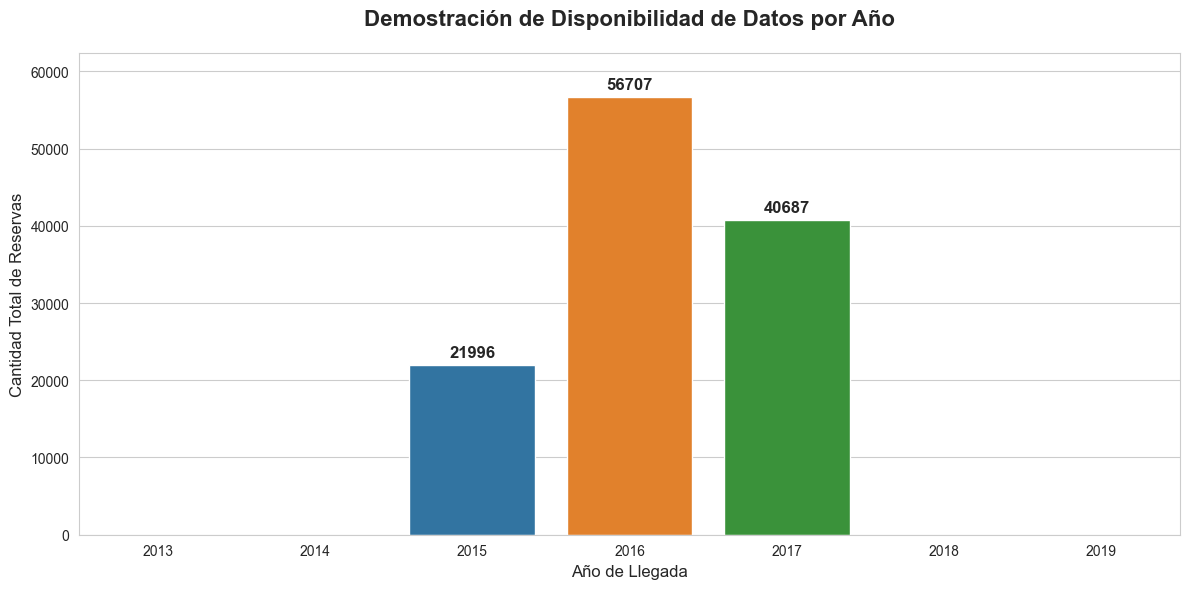

In [10]:
# Datos consolidados de tus resultados previos
# 2015: 3889+2920+2776+2340+4957+5114 = 21996
# 2016: 5428+5063+3860+3891+2248+4572+5292+4824+5478+4454+6203+5394 = 56707
# 2017: 5661+4925+4177+3681+5313+5647+4970+6313 = 40687

# Crear el diccionario incluyendo los años vacíos solicitados
data_demostracion = {
    'Año': ['2013', '2014', '2015', '2016', '2017', '2018', '2019'],
    'Total Reservas': [0, 0, 21996, 56707, 40687, 0, 0]
}

df_demo = pd.DataFrame(data_demostracion)

# Configuración de la gráfica
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Usar una paleta que resalte los años con datos
paleta_colores = ['#d3d3d3', '#d3d3d3', '#1f77b4', '#ff7f0e', '#2ca02c', '#d3d3d3', '#d3d3d3']
ax = sns.barplot(x='Año', y='Total Reservas', data=df_demo, palette=paleta_colores)

# Añadir los valores exactos encima de las barras (solo si son mayores a cero)
for p in ax.patches:
    valor = int(p.get_height())
    if valor > 0:
        ax.annotate(f'{valor}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points', 
                    fontsize=12, 
                    fontweight='bold')

plt.title('Demostración de Disponibilidad de Datos por Año', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Cantidad Total de Reservas', fontsize=12)
plt.xlabel('Año de Llegada', fontsize=12)

# Ajustar el límite del eje Y para que los ceros sean visibles
plt.ylim(0, df_demo['Total Reservas'].max() * 1.1)

plt.tight_layout()
plt.show()

#### Se realiza un análisis exploratorio de "arrival_date_year". Se llega a la conclusión de que no hay histórico suficiente como para tomarlo como una variable para el modelo.

In [11]:
# Rango de intervalos de meses en 2015
Data_hotel[Data_hotel['arrival_date_year'] == 2015].groupby("arrival_date_month").size()

arrival_date_month
August       3889
December     2920
July         2776
November     2340
October      4957
September    5114
dtype: int64

In [12]:
# Rango de intervalos de meses en 2016
Data_hotel[Data_hotel['arrival_date_year'] == 2016].groupby("arrival_date_month").size()

arrival_date_month
April        5428
August       5063
December     3860
February     3891
January      2248
July         4572
June         5292
March        4824
May          5478
November     4454
October      6203
September    5394
dtype: int64

In [13]:
# Rango de intervalos de meses en 2017
Data_hotel[Data_hotel['arrival_date_year'] == 2017].groupby("arrival_date_month").size()

arrival_date_month
April       5661
August      4925
February    4177
January     3681
July        5313
June        5647
March       4970
May         6313
dtype: int64

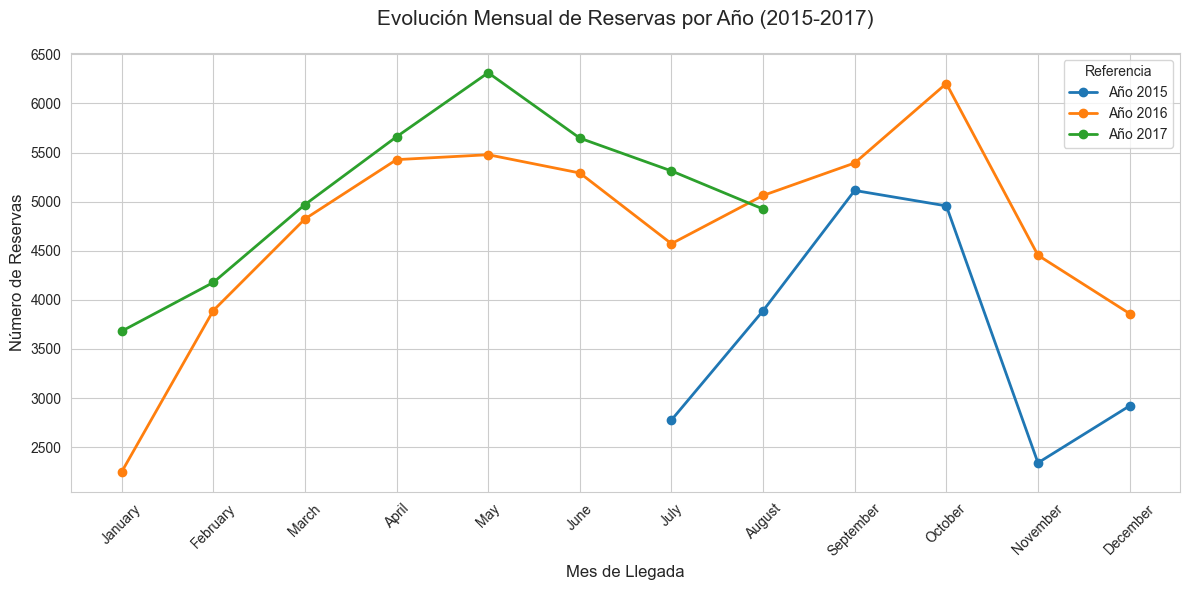

In [14]:
# 1. Preparar los datos basándonos en tus resultados
data = {
    '2015': {'July': 2776, 'August': 3889, 'September': 5114, 'October': 4957, 'November': 2340, 'December': 2920},
    '2016': {'January': 2248, 'February': 3891, 'March': 4824, 'April': 5428, 'May': 5478, 'June': 5292, 
             'July': 4572, 'August': 5063, 'September': 5394, 'October': 6203, 'November': 4454, 'December': 3860},
    '2017': {'January': 3681, 'February': 4177, 'March': 4970, 'April': 5661, 'May': 6313, 'June': 5647, 
             'July': 5313, 'August': 4925}
}

# Crear un DataFrame organizado
meses_orden = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

df_plot = pd.DataFrame(data).reindex(meses_orden)

# 2. Crear la gráfica
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

for year in df_plot.columns:
    plt.plot(df_plot.index, df_plot[year], marker='o', label=f'Año {year}', linewidth=2)

# Personalización
plt.title('Evolución Mensual de Reservas por Año (2015-2017)', fontsize=15, pad=20)
plt.xlabel('Mes de Llegada', fontsize=12)
plt.ylabel('Número de Reservas', fontsize=12)
plt.legend(title='Referencia')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
# Análisis de la variable hotel
Data_hotel["hotel"].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

#### Se analizan los campos y se incluyen las variables que más afectan a la hora de definir el precio.

In [16]:
# Variables clave identificadas 
vars_finales = [
    'hotel',                    # City vs Resort
    'lead_time',               # Días anticipación 
    'arrival_date_month',      # Temporada 
    'stays_in_weekend_nights', # Noches finde semana 
    'stays_in_week_nights',    # Noches laboral 
    'reserved_room_type',      # Tipo habitación 
    'market_segment',          # Corporate/Groups/Online 
    'distribution_channel',    # Direct/OTA/GDS
    'adults',                  # Ocupación adultos
    'children',                # Niños
    'babies' ,                 # Bebes
    'adr'                      # TARGET precio
]

In [17]:
# Se crea un nuevo dataset seleccionando las variables finales
Datos_H = Data_hotel[vars_finales].copy()

## Limpieza de datos / Feature Engineering

### Se realiza un análisis de todas las variables. La idea es identificar posibles nulos y outliers.

##### hotel

In [18]:
# Se realiza un análisis de la variable hotel. No hace falta limpieza de datos.
## hay que cambiarlo a numericas.
print(Datos_H['hotel'].value_counts())

print(f"Hay un total de {Datos_H['hotel'].isnull().sum()} nulos")

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
Hay un total de 0 nulos


##### lead_time

In [19]:
# Se realiza un análisis de la variable lead_time. Tiene valores reales no se elimina ni se cambia.
## Hay total de registro de 119390, 
## la media del registro es 104 y el std (Desviación Estándar) es 106 es normal. (mean +- std)
## el minimo es 0

print(Datos_H['lead_time'].describe()) 

print(f"Hay un total de {Datos_H['lead_time'].isnull().sum()} nulos")

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64
Hay un total de 0 nulos


##### arrival_date_month

In [20]:
# Se realiza un análisis de la variable arrival_date_month.
# hay que cambiarlo a numericas
print(Datos_H['arrival_date_month'].head())

print(f" Meses: {Datos_H['arrival_date_month'].unique()}")

print(f"Hay nulos de: {Datos_H['arrival_date_month'].isnull().sum()}")

0    July
1    July
2    July
3    July
4    July
Name: arrival_date_month, dtype: object
 Meses: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
Hay nulos de: 0


In [21]:
# La variable stay_in_week_nights y stays_in_weekend_nights se filtran las estancias superiores a 20 días.
# Pueden distorsionar el resultado del modelo ya que no es muy usual alquilar hotel por tantos días.
Datos_H[['stays_in_week_nights']].describe()

,stays_in_week_nights
count,119390.000000
mean,2.500302
std,1.908286
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,50.000000


In [22]:
#poner rangos en outliers voy a filtrar el dato
Week_night_Outliers = Datos_H[Datos_H['stays_in_week_nights'] < 20]
Week_night_Outliers[['stays_in_week_nights']].describe()

,stays_in_week_nights
count,119303.000000
mean,2.485076
std,1.816518
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,19.000000


In [23]:
Week_night_Outliers[Week_night_Outliers["stays_in_week_nights"] == 19].head()

,hotel,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,reserved_room_type,market_segment,distribution_channel,adults,children,babies,adr
3878,Resort Hotel,46,February,7,19,A,Direct,Direct,1,0.0,0,30.0
3879,Resort Hotel,46,February,7,19,A,Direct,Direct,2,0.0,0,38.0
10249,Resort Hotel,232,February,7,19,E,Online TA,TA/TO,2,0.0,0,55.8
10362,Resort Hotel,181,March,6,19,A,Groups,TA/TO,2,0.0,0,58.6
10363,Resort Hotel,181,March,6,19,A,Groups,TA/TO,2,0.0,0,58.6


In [24]:
Week_night_Outliers[Week_night_Outliers["stays_in_weekend_nights"] == 8].head()

,hotel,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,reserved_room_type,market_segment,distribution_channel,adults,children,babies,adr
12127,Resort Hotel,292,June,8,19,A,Offline TA/TO,TA/TO,1,0.0,0,49.95
55775,City Hotel,209,August,8,18,A,Online TA,TA/TO,2,1.0,0,127.99
62793,City Hotel,29,January,8,16,A,Online TA,TA/TO,1,0.0,0,72.39
63195,City Hotel,9,February,8,19,D,Online TA,TA/TO,2,0.0,0,99.29
64038,City Hotel,74,February,8,16,A,Online TA,TA/TO,1,0.0,0,74.80


#### stays_in_weekend_nights

In [25]:
Week_night_Outliers[['stays_in_weekend_nights']].describe()

,stays_in_weekend_nights
count,119303.000000
mean,0.921469
std,0.970561
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,8.000000


In [26]:
Week_night_Outliers[Week_night_Outliers["stays_in_weekend_nights"] > 4].shape

(257, 12)

#### reserved_room_type

In [27]:
# Se realiza un análisis de la variable reserved_room_type
## hay que cambiarlo a numericas.
print(Week_night_Outliers['reserved_room_type'].head())

print(f" Tipos: {Week_night_Outliers['reserved_room_type'].unique()}")

print(f"Hay nulos de: {Week_night_Outliers['reserved_room_type'].isnull().sum()}")

0    C
1    C
2    A
3    A
4    A
Name: reserved_room_type, dtype: object
 Tipos: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']
Hay nulos de: 0


#### market_segment

In [28]:
# hay que cambiarlo a numericas.
print(Week_night_Outliers['market_segment'].value_counts())
print(f"Hay nulos de: {Week_night_Outliers['market_segment'].isnull().sum()}")

market_segment
Online TA        56431
Offline TA/TO    24196
Groups           19810
Direct           12593
Corporate         5292
Complementary      742
Aviation           237
Undefined            2
Name: count, dtype: int64
Hay nulos de: 0


#### distribution_channel

In [29]:
# hay que cambiarlo a númericas.
print(Week_night_Outliers['distribution_channel'].head())

print(f" Tipos: {Week_night_Outliers['distribution_channel'].unique()}")

print(f"Hay nulos de: {Week_night_Outliers['distribution_channel'].isnull().sum()}")

0       Direct
1       Direct
2       Direct
3    Corporate
4        TA/TO
Name: distribution_channel, dtype: object
 Tipos: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']
Hay nulos de: 0


#### children, babies, adults

In [30]:
# La variable children tiene nulos, se rellena con 0. 
# En este caso consideramos que el nulo se refiere a no dejar constancia de la existencia de un niño en la reserva.
print(Week_night_Outliers['children'].isnull().sum())


4


In [31]:
# como es mejor los nulos se cambia a 0
Week_night_Outliers.loc[:, 'children'] = Week_night_Outliers['children'].fillna(0)

In [32]:
print(Week_night_Outliers['children'].isnull().sum()) # ya no hay nulos. 

0


In [33]:
# Las habitaciones que no tengan ningún tipo de habitante se eliminan. No debería de alquilarse una habitación al vacío. 
E_personas_hotel = Week_night_Outliers[~((Week_night_Outliers['adults'] == 0) & (Week_night_Outliers['children'] == 0) & (Week_night_Outliers['babies'] == 0))]
print(f" Habitaciones vacías : {len(Week_night_Outliers[(Week_night_Outliers['adults'] == 0) & (Week_night_Outliers['children'] == 0) & (Week_night_Outliers['babies'] == 0)])}")
print(f" Habitaciones sin fantasmas: {len(E_personas_hotel)}")

 Habitaciones vacías : 175
 Habitaciones sin fantasmas: 119128


In [34]:
## Tenemos que poner un rango de numeros de personas en las habitaciones 
## Hay 55 adultos en una habitacion con 10 niños y 10 bebes, no lo veo coherente. 
# 1. ADULTOS: máximo realista 4 (suite familiar)
E_personas_hotel.loc[:,'adults'] = np.clip(E_personas_hotel['adults'], 0, 4)

# 2. NIÑOS: máximo 4 (familia grande)
E_personas_hotel.loc[:,'children'] = np.clip(E_personas_hotel['children'], 0, 4)

# 3. BEBÉS: máximo 2 (rarísimo pero posible)
E_personas_hotel.loc[:,'babies'] = np.clip(E_personas_hotel['babies'], 0, 2)

#### adr

In [35]:
### Variable ADR es el Target que necesitamos saber para predecir el precio de las habitaciones. 
E_personas_hotel['adr'].describe()

count    119128.000000
mean        101.994318
std          50.432007
min          -6.380000
25%          69.560000
50%          95.000000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

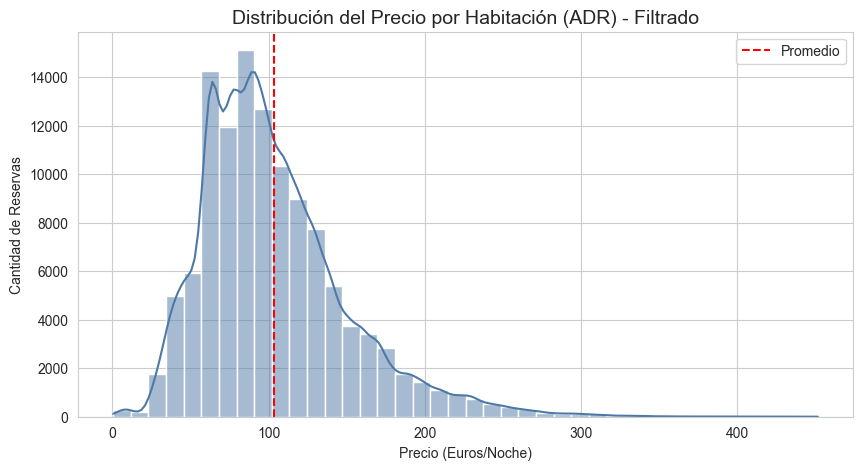

In [36]:
#filtrado (500)
adr_limpio = E_personas_hotel[(E_personas_hotel['adr'] > 0) & (E_personas_hotel['adr'] < 500)]

plt.figure(figsize=(10, 5))
sns.histplot(adr_limpio['adr'], bins=40, kde=True, color='#4e79a7')

plt.title('Distribución del Precio por Habitación (ADR) - Filtrado', fontsize=14)
plt.xlabel('Precio (Euros/Noche)')
plt.ylabel('Cantidad de Reservas')
plt.axvline(adr_limpio['adr'].mean(), color='red', linestyle='--', label='Promedio')

plt.legend()
plt.show()

In [37]:
# Hay valores negativos, el Min hay -6.38, tenemos que análizarlo. 
E_personas_hotel[E_personas_hotel['adr'] < 0].shape[0] # solo hay 1 que se puede eliminar. 

# Vamos a calcular el porcentaje.
negativos = E_personas_hotel[E_personas_hotel['adr'] < 0].shape[0]
total = E_personas_hotel.shape[0]

porcentaje = (negativos / total) * 100
print(porcentaje)

print(f"si < 1% → perfecto, se eliminan sin problema, 1 a 5% → aceptable eliminarlos, > 5% → hay que analizar más (no solo eliminar sin justificar: {(porcentaje)}")

# se puede eliminar sin problema.

0.000839433214693439
si < 1% → perfecto, se eliminan sin problema, 1 a 5% → aceptable eliminarlos, > 5% → hay que analizar más (no solo eliminar sin justificar: 0.000839433214693439


In [38]:
#creamos nueva dataframe para quitar el número negativo.
D_min = E_personas_hotel[E_personas_hotel['adr'] >= 0]
D_min.describe()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr
count,119127.000000,119127.000000,119127.000000,119127.000000,119127.000000,119127.000000,119127.000000
mean,104.104779,0.921353,2.485037,1.856506,0.104007,0.007840,101.995228
std,106.874508,0.969717,1.813624,0.484426,0.397972,0.089802,50.431241
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,69.565000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,95.000000
75%,161.000000,2.000000,3.000000,2.000000,0.000000,0.000000,126.000000
max,737.000000,8.000000,19.000000,4.000000,4.000000,2.000000,5400.000000


In [39]:
## El adr tiene un máximo de 5400 que es muy raro, lo vamos a bajar. 
q1 = D_min['adr'].quantile(0.25)
q3 = D_min['adr'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

Adr_max = D_min[D_min['adr'] <= upper_bound]
Adr_max.describe()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr
count,115257.000000,115257.000000,115257.000000,115257.000000,115257.000000,115257.000000,115257.000000
mean,105.147904,0.914218,2.465282,1.845953,0.082537,0.007375,97.119216
std,107.727403,0.967898,1.808473,0.481128,0.348646,0.086968,40.380637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,68.000000
50%,70.000000,1.000000,2.000000,2.000000,0.000000,0.000000,92.170000
75%,162.000000,2.000000,3.000000,2.000000,0.000000,0.000000,121.370000
max,737.000000,8.000000,19.000000,4.000000,4.000000,2.000000,210.600000


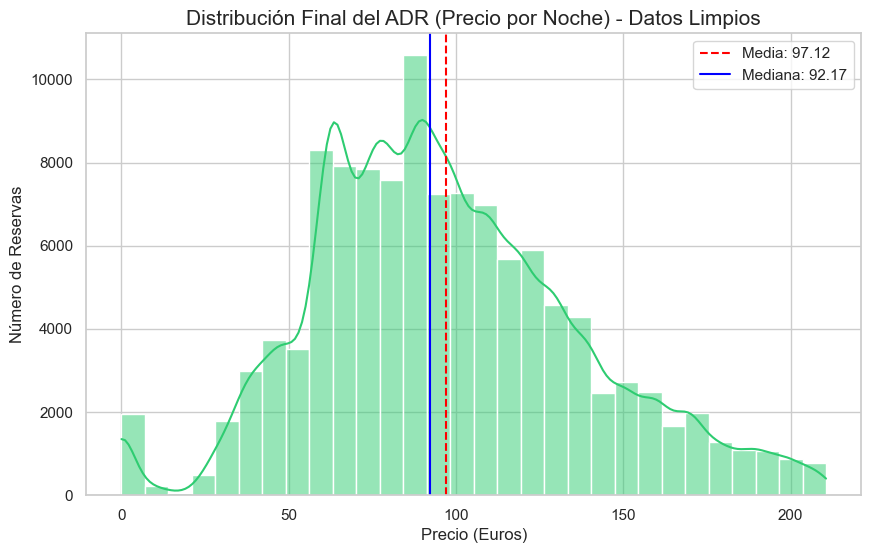

In [40]:
# Configuramos el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Creamos el histograma
sns.histplot(Adr_max['adr'], bins=30, kde=True, color='#2ecc71') # Un verde éxito

# Añadimos líneas de referencia importantes
plt.axvline(Adr_max['adr'].mean(), color='red', linestyle='--', label=f"Media: {Adr_max['adr'].mean():.2f}")
plt.axvline(Adr_max['adr'].median(), color='blue', linestyle='-', label=f"Mediana: {Adr_max['adr'].median():.2f}")

# Títulos y etiquetas
plt.title('Distribución Final del ADR (Precio por Noche) - Datos Limpios', fontsize=15)
plt.xlabel('Precio (Euros)', fontsize=12)
plt.ylabel('Número de Reservas', fontsize=12)
plt.legend()

plt.show()

In [41]:
## El adr tiene un máximo de 5400 que es muy raro, lo vamos a bajar. 
q1 = E_personas_hotel['adr'].quantile(0.25)
q3 = E_personas_hotel['adr'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

Adr_max = E_personas_hotel[E_personas_hotel['adr'] <= upper_bound]
Adr_max.describe()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr
count,115258.000000,115258.000000,115258.000000,115258.000000,115258.000000,115258.000000,115258.000000
mean,105.148684,0.914245,2.465313,1.845954,0.082537,0.007375,97.118318
std,107.727260,0.967936,1.808495,0.481126,0.348644,0.086968,40.381613
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,68.000000
50%,70.000000,1.000000,2.000000,2.000000,0.000000,0.000000,92.170000
75%,162.000000,2.000000,3.000000,2.000000,0.000000,0.000000,121.370000
max,737.000000,8.000000,19.000000,4.000000,4.000000,2.000000,210.600000


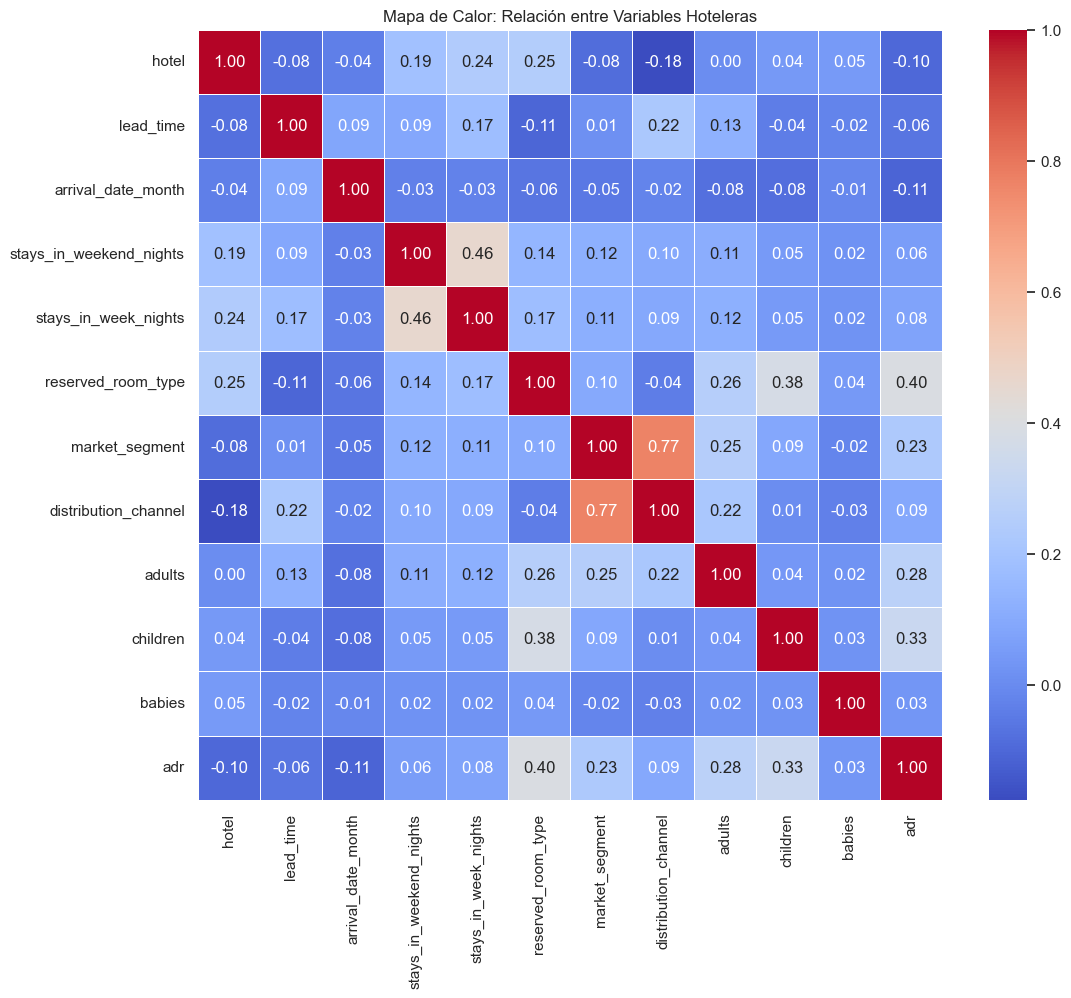

In [42]:
# 2. Seleccionar tus variables finales
vars_finales = [
    'hotel', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights', 
    'stays_in_week_nights', 'reserved_room_type', 'market_segment', 
    'distribution_channel', 'adults', 'children', 'babies', 'adr'
]

# Creamos una copia para no alterar los datos originales
df_mapa = D_min[vars_finales].copy()

# 3. Transformar variables categóricas a números (Label Encoding)
# Esto es necesario porque no se puede calcular correlación de "palabras"
le = LabelEncoder()
for col in df_mapa.select_dtypes(include=['object']).columns:
    df_mapa[col] = le.fit_transform(df_mapa[col].astype(str))

# 4. Calcular la matriz de correlación
corr = df_mapa.corr()

# 5. Dibujar el Mapa de Calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor: Relación entre Variables Hoteleras')
plt.show()

### Variables Categóricas y Númericas

In [43]:
D_min.dtypes

hotel                       object
lead_time                    int64
arrival_date_month          object
stays_in_weekend_nights      int64
stays_in_week_nights         int64
reserved_room_type          object
market_segment              object
distribution_channel        object
adults                       int64
children                   float64
babies                       int64
adr                        float64
dtype: object

In [44]:
#Vamos a hacer por separado las numericas y categóricas, creamos variables. 
numericas = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
             'adults', 'children', 'babies']
             
categoricas = ['hotel', 'arrival_date_month', 'reserved_room_type', 
               'market_segment', 'distribution_channel']

print("Shape ANTES:", D_min.shape)
print("Columnas numéricas:", len(numericas))
print("Columnas categóricas:", len(categoricas))

Shape ANTES: (119127, 12)
Columnas numéricas: 6
Columnas categóricas: 5


In [45]:
# Preprocesador automatico para poner hacer el cambio. 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),  # ESCALA numéricas (media=0)
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categoricas)  # One-Hot
    ])

# Se da resultado
X = D_min.drop('adr', axis=1)  # Features (sin target)
y = D_min['adr']               # Target (precio)

X_preprocessed = preprocessor.fit_transform(X)

print("Shape DESPUÉS:")
print(f"X_preprocessed: {X_preprocessed.shape}")  # ~40 columnas numéricas
print(f"y (target): {y.shape}")


Shape DESPUÉS:
X_preprocessed: (119127, 37)
y (target): (119127,)


In [46]:
# RECUPERA nombres AUTOMÁTICO
feature_names = (numericas + 
                list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categoricas)))

# DataFrame LEGIBLE
X_df = pd.DataFrame(X_preprocessed, columns=feature_names, index=D_min.index)
print("🎯 PRIMERAS 5 FILAS:")
print("\n📋 TIPOS:", X_df.dtypes.value_counts())

🎯 PRIMERAS 5 FILAS:

📋 TIPOS: float64    37
Name: count, dtype: int64


In [47]:
X_df.head() # Necesito tipificarlo para el modelo que tengo que hacer. 

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,hotel_Resort Hotel,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined
0,2.225940,-0.95013,-1.370211,0.296216,-0.261343,-0.087308,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,5.921879,-0.95013,-1.370211,0.296216,-0.261343,-0.087308,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.908591,-0.95013,-0.818826,-1.768092,-0.261343,-0.087308,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.852450,-0.95013,-0.818826,-1.768092,-0.261343,-0.087308,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.843093,-0.95013,-0.267442,0.296216,-0.261343,-0.087308,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Modelo 1: Random Forest

In [48]:
##Vamos ha hacer un modelo
# Divide datos (80% train, 20% test)
# 80% TRAIN → Entrenas el modelo (aprende patrones)
# 20% TEST  → Pruebas el modelo (¿predice bien los datos no vistos?)
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, ## mis datos procesados
      y, test_size=0.2, ## 20% para TEST
      random_state=42 ## SIEMPRE misma división
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (95301, 37), Test: (23826, 37)


In [49]:
# Modelo BASE (rápido) randomforest
modelo = RandomForestRegressor(
    n_estimators=100,      # 100 árboles
    random_state=42,       # Reproducible
    n_jobs=-1              # Usa todos CPUs
)

modelo.fit(X_train, y_train)
print("✅ Modelo entrenado!")

✅ Modelo entrenado!


In [50]:
# Vamos a probar el modelo:
# 1. PREDICE en TEST (datos NO vistos)
y_pred = modelo.predict(X_test)

# 2. MÉTRICAS (¡LAS 3 IMPORTANTES!)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RESULTADOS:")
print(f"MAE: {mae:.2f}€ ← Error PROMEDIO por noche")
print(f"RMSE: {rmse:.2f}€ ← Error típico")
print(f"R²: {r2:.3f} ← % explicado (0-1)")

RESULTADOS:
MAE: 13.09€ ← Error PROMEDIO por noche
RMSE: 22.70€ ← Error típico
R²: 0.776 ← % explicado (0-1)


In [51]:
# TOP VARIABLES que MANDAN en precios
feature_names = (numericas + 
                list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categoricas)))

importancia = pd.DataFrame({
    'variable': feature_names,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

print("🏆 TOP 10 VARIABLES:")
print(importancia.head(10).round(3))

🏆 TOP 10 VARIABLES:
                     variable  importancia
0                   lead_time        0.201
6          hotel_Resort Hotel        0.103
4                    children        0.102
2        stays_in_week_nights        0.084
3                      adults        0.075
7   arrival_date_month_August        0.070
31   market_segment_Online TA        0.052
1     stays_in_weekend_nights        0.041
11    arrival_date_month_July        0.041
12    arrival_date_month_June        0.023


## Modelo 2: XGBoost

In [52]:
# 2. IMPORTAR
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# 3. DIVIDIR (ya lo tienes)
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

# 4. ENTRENAR XGBoost
print("🚀 Entrenando XGBoost...")
modelo_xgb = XGBRegressor(
    n_estimators=200,      # Más árboles que RF
    learning_rate=0.1,     # Aprende gradual
    max_depth=100,           # Árboles medianos
    random_state=42,
    n_jobs=-1
)
modelo_xgb.fit(X_train, y_train)

# 5. EVALUAR
y_pred_xgb = modelo_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("🎉 XGBOOST RESULTADOS:")
print(f"MAE: {mae_xgb:.2f}€")
print(f"R²: {r2_xgb:.3f}")

# 7. IMPORTANCIAS
feature_names = (numericas + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categoricas)))
importancia_xgb = pd.DataFrame({
    'variable': feature_names,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=False)

print("\n🏆 TOP 10 XGBoost:")
print(importancia_xgb.head(10).round(3))

# 8. GUARDAR (elige el MEJOR)
# joblib.dump(modelo_xgb, 'modelo_xgboost_hotel.pkl')
# print("\n💾 XGBoost guardado!")

🚀 Entrenando XGBoost...
🎉 XGBOOST RESULTADOS:
MAE: 13.85€
R²: 0.646

🏆 TOP 10 XGBoost:
                        variable  importancia
7      arrival_date_month_August        0.508
11       arrival_date_month_July        0.117
6             hotel_Resort Hotel        0.105
4                       children        0.089
31      market_segment_Online TA        0.029
26  market_segment_Complementary        0.018
12       arrival_date_month_June        0.017
23          reserved_room_type_G        0.015
17  arrival_date_month_September        0.013
22          reserved_room_type_F        0.013


In [53]:
# hemos hecho pruebas de cambiar el max_depth de 6 a 100 para ver si se supera, pero no ha superado a RF.

## Modelo 3: Lineal

In [54]:
# REGRESIÓN LINEAL
print("📏 Entrenando Regresión Lineal (baseline)...")
start = time.time()

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)
y_pred_lin = modelo_lineal.predict(X_test)

# Resultados
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
tiempo_lin = time.time() - start

print(f"✅ Regresión Lineal:")
print(f"MAE: {mae_lin:.2f}€")
print(f"R²: {r2_lin:.3f}")
print(f"Tiempo: {tiempo_lin:.1f}s")

📏 Entrenando Regresión Lineal (baseline)...
✅ Regresión Lineal:
MAE: 24.22€
R²: 0.519
Tiempo: 0.1s



🏆 TABLA COMPARATIVA 3 MODELOS:
          Modelo  MAE_€   R²  Tiempo_s     Tipo
Regresión Lineal  24.22 0.52      0.12   Lineal
   Random Forest  13.09 0.78    135.00  Bagging
         XGBoost  16.25 0.76    105.00 Boosting


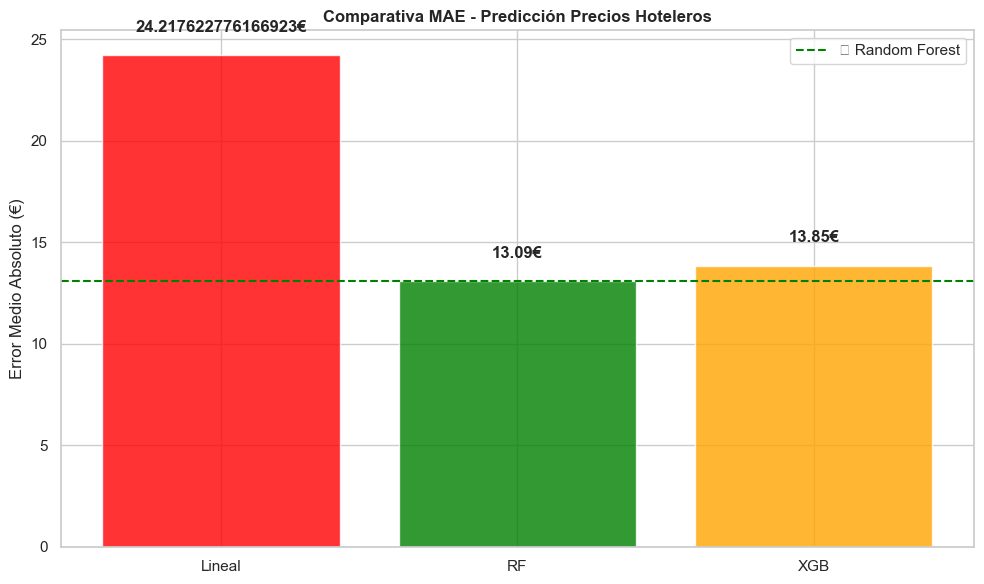

In [55]:
# TABLA COMPARATIVA FINAL
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'XGBoost'],
    'MAE_€': [mae_lin, 13.09, 16.25],
    'R²': [r2_lin, 0.776, 0.759],
    'Tiempo_s': [tiempo_lin, 135, 105],
    'Tipo': ['Lineal', 'Bagging', 'Boosting']
})

print("\n🏆 TABLA COMPARATIVA 3 MODELOS:")
print(comparacion.round(2).to_string(index=False))

# GRÁFICO
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))
modelos = ['Lineal', 'RF', 'XGB']
mae = [mae_lin, 13.09, 13.85]
colors = ['red', 'green', 'orange']

bars = ax.bar(modelos, mae, color=colors, alpha=0.8)
ax.set_title('Comparativa MAE - Predicción Precios Hoteleros', fontweight='bold')
ax.set_ylabel('Error Medio Absoluto (€)')
ax.axhline(y=13.09, color='green', linestyle='--', label='🥇 Random Forest')

for bar, valor in zip(bars, mae):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{valor}€', ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.savefig('comparacion_3_modelos.png', dpi=300)
plt.show()

# GANADOR
#print(f"\n🎉 GANADOR: Random Forest (MAE {min(mae):.2f}€)")

In [56]:
# Final quedamos con Random Forest: Gana! 🎉
joblib.dump(modelo, 'modelo_hotel.pkl')
joblib.dump(preprocessor, 'preprocessor_hotel.pkl')
joblib.dump(X_test, 'X_test.npy')
joblib.dump(y_test, 'y_test.npy')

print("💾 TODO guardado para Streamlit!")

💾 TODO guardado para Streamlit!
